In [1]:
import json
import networkx as nx
import pandas as pd
from network import *
# Load JSON files
with open(r"main_authors.json", "r", encoding="utf-8") as f:
    main_authors = json.load(f)

with open(r"all_collaborations.json", "r", encoding="utf-8") as f:
    all_collaborations = json.load(f)

# Set of NTU faculty PIDs
faculty_pids = {author["pid"] for author in main_authors}

In [19]:
main_authors_collaborations_csv = 'main_authors_collaborations.csv'
faculty_csv = 'Faculty.csv'
df = pd.read_csv(main_authors_collaborations_csv)
faculty_info = pd.read_csv(faculty_csv)

# Merge faculty information with collaboration data
# Rename columns from faculty_info to avoid conflicts

# Merge on author_pid = pid, keeping only the needed columns
df = pd.merge(
    df,
    faculty_info[['pid', 'Area', 'Management', 'Position']],
    left_on='author_pid',
    right_on='pid',
    how='left'
)
df = df.rename(columns={
    'Area': 'author_area',
    'Management': 'author_management',
    'Position': 'author_position'
})
# Drop the redundant pid column from the merge
df = df.drop(columns=['pid'])

df.head()

,colab_id,author_pid,author_name,year,collaborator_pid,collaborator_name,author_area,author_management,author_position
0,1,15/3108,Alexei Sourin,2025,15/3108,Alexei Sourin,Computer Graphics,N,Associate Professor
1,2,15/3108,Alexei Sourin,2024,15/3108,Alexei Sourin,Computer Graphics,N,Associate Professor
2,3,15/3108,Alexei Sourin,2024,15/3108,Alexei Sourin,Computer Graphics,N,Associate Professor
3,4,15/3108,Alexei Sourin,2024,15/3108,Alexei Sourin,Computer Graphics,N,Associate Professor
4,5,15/3108,Alexei Sourin,2023,15/3108,Alexei Sourin,Computer Graphics,N,Associate Professor


In [2]:
networks = build_collaboration_networks('main_authors_collaborations.csv')

collaboration_network = networks[sorted(networks.keys())[-1]]
print_network_info(networks)



year: 1986 
  number of nodes: 2
  number of edges: 0

year: 1987 
  number of nodes: 2
  number of edges: 0

year: 1988 
  number of nodes: 3
  number of edges: 0

year: 1990 
  number of nodes: 6
  number of edges: 0

year: 1991 
  number of nodes: 9
  number of edges: 0

year: 1992 
  number of nodes: 13
  number of edges: 0

year: 1993 
  number of nodes: 16
  number of edges: 0

year: 1994 
  number of nodes: 19
  number of edges: 0

year: 1995 
  number of nodes: 23
  number of edges: 1
  the most frequent colaboration(cumulative): Seah Hock Soon and Thambipillai Srikanthan (for 1.0 times)

year: 1996 
  number of nodes: 26
  number of edges: 3
  the most frequent colaboration(cumulative): Wentong Cai 0001 and Bu-Sung Lee (for 2.0 times)

year: 1997 
  number of nodes: 28
  number of edges: 7
  the most frequent colaboration(cumulative): Wentong Cai 0001 and Bu-Sung Lee (for 3.0 times)

year: 1998 
  number of nodes: 31
  number of edges: 10
  the most frequent colaboration(cumu

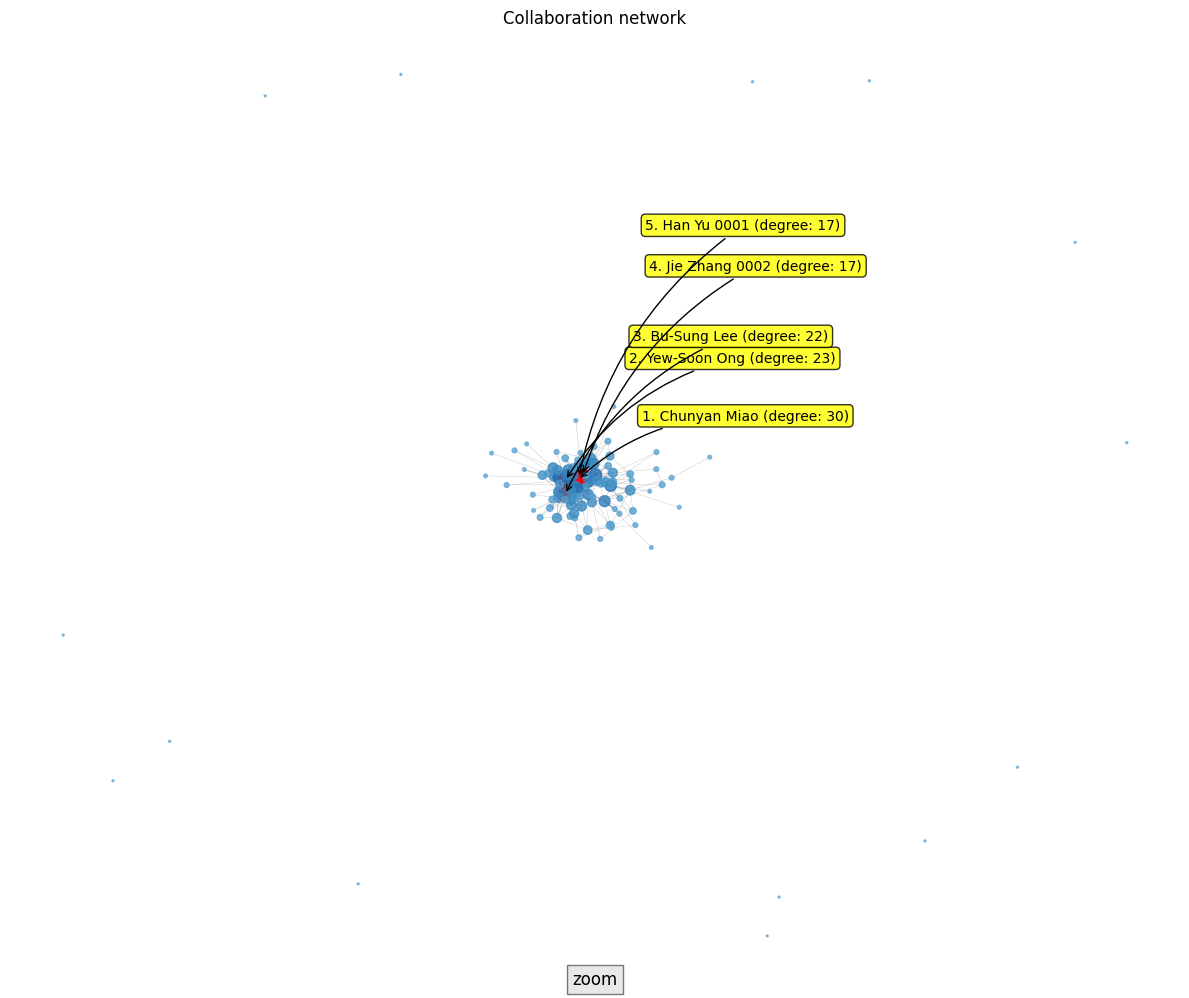

In [4]:
networks = build_collaboration_networks('main_authors_collaborations.csv')
dashboard = create_network_dashboard(networks)
display(dashboard)  # 在Jupyter中显示仪表板

In [ ]:
from networkx.algorithms.cluster import average_clustering
from networkx.algorithms.shortest_paths.generic import average_shortest_path_length
from networkx.algorithms.community import modularity, greedy_modularity_communities

# Compute clustering coefficient
clustering_coefficient = average_clustering(collaboration_network)
print(f"Clustering Coefficient: {clustering_coefficient}")

# Compute average path length
if nx.is_connected(collaboration_network):
    avg_path_length = average_shortest_path_length(collaboration_network)
    print(f"Average Path Length: {avg_path_length}")
else:
    print("The network is not connected, so average path length cannot be computed.")

# Compute modularity
communities = greedy_modularity_communities(collaboration_network)
modularity_value = modularity(collaboration_network, communities)
print(f"Modularity: {modularity_value}")

Clustering Coefficient: 0.26774814690071846
The network is not connected, so average path length cannot be computed.
Modularity: 0.33170874808884326


In [9]:
# Get the number of nodes (N) and edges (L) from the real network
N = collaboration_network.number_of_nodes()
L = collaboration_network.number_of_edges()

# Generate a random network with the same N and L
random_network = nx.gnm_random_graph(N, L)

# Print basic information about the random network
print(f"Random Network: {N} nodes, {L} edges")

Random Network: 109 nodes, 329 edges


In [13]:
from networkx.algorithms.cluster import average_clustering
from networkx.algorithms.distance_measures import diameter

# Compute clustering coefficient for random network
random_clustering_coefficient = average_clustering(random_network)
print(f"Random Network Clustering Coefficient: {random_clustering_coefficient}")

# Check if networks are connected before computing diameter
if nx.is_connected(random_network):
    random_diameter = diameter(random_network)
    print(f"\nRandom Network Diameter: {random_diameter}")
else:
    print("\nRandom network is not connected, computing diameter of largest component")
    largest_cc = max(nx.connected_components(random_network), key=len)
    random_subgraph = random_network.subgraph(largest_cc)
    random_diameter = diameter(random_subgraph)
    print(f"Random Network Diameter (largest component): {random_diameter}")

if nx.is_connected(collaboration_network):
    real_diameter = diameter(collaboration_network)
    print(f"Real Network Diameter: {real_diameter}")
else:
    print("Real network is not connected, computing diameter of largest component")
    largest_cc = max(nx.connected_components(collaboration_network), key=len)
    real_subgraph = collaboration_network.subgraph(largest_cc)
    real_diameter = diameter(real_subgraph)
    print(f"Real Network Diameter (largest component): {real_diameter}")

Random Network Clustering Coefficient: 0.04751624522266724

Random Network Diameter: 6
Real network is not connected, computing diameter of largest component
Real Network Diameter (largest component): 6


Average Node Degree in Real Network: 6.04


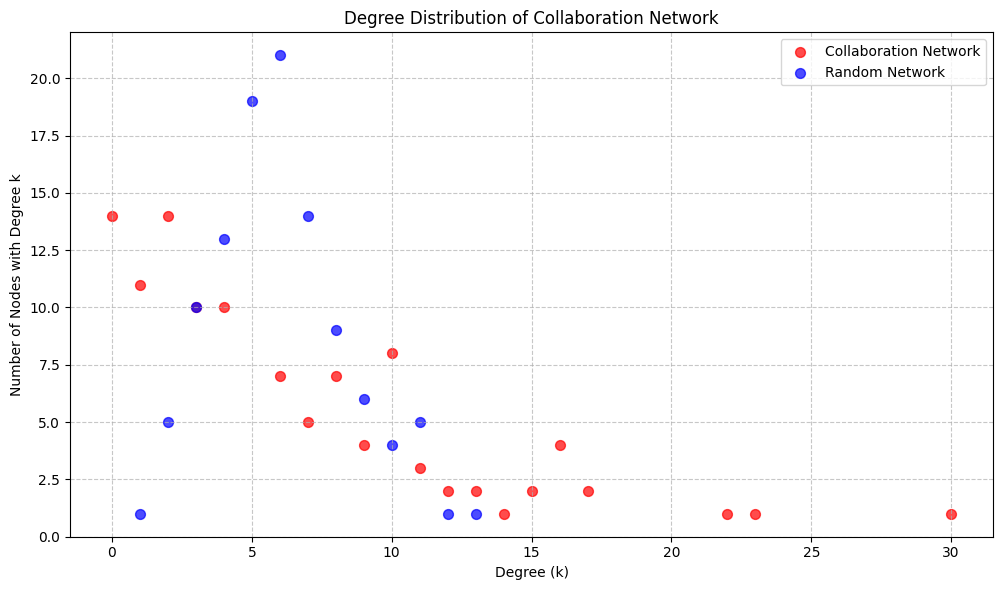

In [14]:
import numpy as np
from collections import Counter

import matplotlib.pyplot as plt

# Calculate average node degree for real network
avg_degree_real = sum(dict(collaboration_network.degree()).values()) / len(collaboration_network)
print(f"Average Node Degree in Real Network: {avg_degree_real:.2f}")

# Calculate degree distribution for real network
degrees = [d for _, d in collaboration_network.degree()]
degree_counts = Counter(degrees)

# Convert to arrays for plotting
unique_degrees = sorted(degree_counts.keys())
count_values = [degree_counts[d] for d in unique_degrees]

# Create scatter plot with log scales
plt.figure(figsize=(10, 6))
plt.scatter(unique_degrees, count_values, color='red', alpha=0.7, s=50)
# plt.plot(unique_degrees, count_values, 'r--', alpha=0.5)  # Add connecting line

plt.title("Degree Distribution of Collaboration Network")
plt.xlabel("Degree (k)")
plt.ylabel("Number of Nodes with Degree k")
# plt.xscale("log")  # Log scale for x-axis

# plt.yscale("log")  # Log scale for y-axis
plt.grid(True, which="both", linestyle='--', alpha=0.7)

# Add text for average degree
# plt.text(0.95, 0.95, f"Avg Degree: {avg_degree_real:.2f}", 
#          transform=plt.gca().transAxes, 
#          horizontalalignment='right',
#          verticalalignment='top',
#          bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
# Calculate degree distribution for random network
random_degrees = [d for _, d in random_network.degree()]
random_degree_counts = Counter(random_degrees)

# Convert to arrays for plotting
random_unique_degrees = sorted(random_degree_counts.keys())
random_count_values = [random_degree_counts[d] for d in random_unique_degrees]

# Add random network data to the same plot
plt.scatter(random_unique_degrees, random_count_values, color='blue', alpha=0.7, s=50)
# plt.plot(random_unique_degrees, random_count_values, 'b--', alpha=0.5)  # Add connecting line

# Add legend
plt.legend(['Collaboration Network', 'Random Network'])

# Calculate average degree for random network
avg_degree_random = sum(dict(random_network.degree()).values()) / len(random_network)

# Update text annotation to include both averages
# plt.gca().texts[0].set_text(f"Real Avg Degree: {avg_degree_real:.2f}\nRandom Avg Degree: {avg_degree_random:.2f}")

plt.show()

# Optional: Compare to random network
# avg_degree_random = sum(dict(random_network.degree()).values()) / len(random_network)
# print(f"Average Node Degree in Random Network: {avg_degree_random:.2f}")

In [67]:
# # Get positions for the nodes using a layout algorithm
# random_pos = nx.spring_layout(random_network)

# # Extract node positions
# random_x_nodes = [random_pos[node][0] for node in random_network.nodes()]
# random_y_nodes = [random_pos[node][1] for node in random_network.nodes()]

# # Extract edge positions and weights
# random_x_edges = []
# random_y_edges = []
# for edge in random_network.edges():
#     random_x_edges += [random_pos[edge[0]][0], random_pos[edge[1]][0], None]
#     random_y_edges += [random_pos[edge[0]][1], random_pos[edge[1]][1], None]

# # Calculate node degrees for node size
# random_node_sizes = [random_network.degree(node) for node in random_network.nodes()]

# # Normalize node sizes for visualization
# random_max_node_size = max(random_node_sizes)
# random_normalized_node_sizes = [size / random_max_node_size * 20 for size in random_node_sizes]

# # Create the edge trace
# random_edge_trace = go.Scatter(
#     x=random_x_edges,
#     y=random_y_edges,
#     mode='lines',
#     line=dict(width=0.5, color='#888'),
#     hoverinfo='none'
# )

# # Create the node trace
# random_node_trace = go.Scatter(
#     x=random_x_nodes,
#     y=random_y_nodes,
#     mode='markers',
#     marker=dict(
#         size=random_normalized_node_sizes,
#         color='blue',
#         line=dict(width=2, color='black')
#     ),
#     text=[f"Node: {node}<br>Degree: {random_network.degree(node)}" for node in random_network.nodes()],
#     hoverinfo='text'
# )

# # Create the figure
# random_fig = go.Figure(data=[random_edge_trace, random_node_trace],
#                        layout=go.Layout(
#                            title='Random Network Visualization with Node Sizes',
#                            showlegend=False,
#                            hovermode='closest',
#                            margin=dict(b=0, l=0, r=0, t=0),
#                            xaxis=dict(showgrid=False, zeroline=False),
#                            yaxis=dict(showgrid=False, zeroline=False)
#                        ))

# # Show the plot
# random_fig.show()

In [112]:
networks = build_collaboration_networks('main_authors_collaborations.csv')
# visualize_network_evolution(networks)

In [18]:
# visualize_network_evolution(networks)



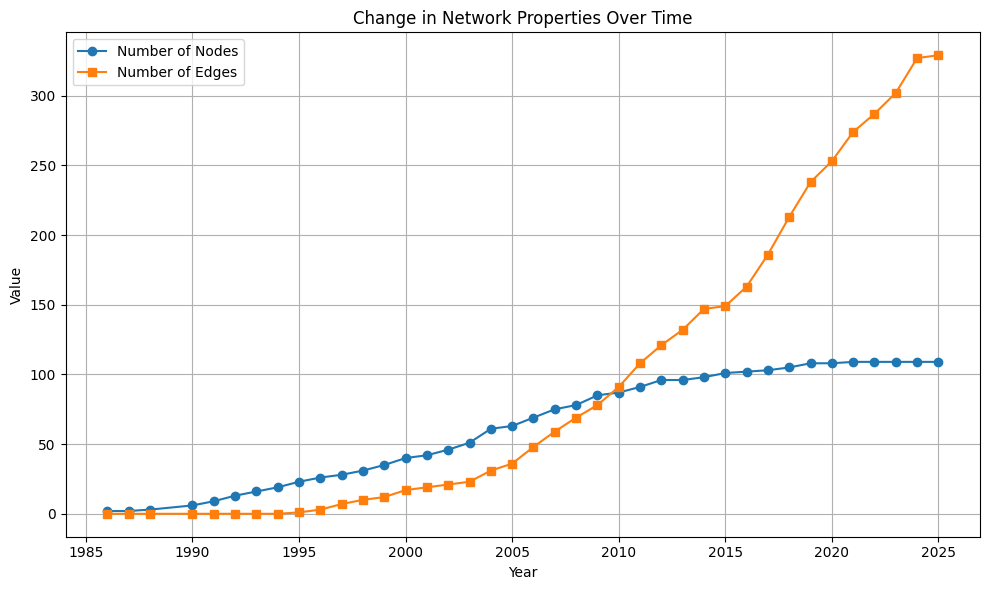

In [16]:
import matplotlib.pyplot as plt

# Prepare data for plotting
years = sorted(networks.keys())
num_nodes = [networks[year].number_of_nodes() for year in years]
num_edges = [networks[year].number_of_edges() for year in years]
avg_degrees = [2 * num_edges[i] / num_nodes[i] if num_nodes[i] > 0 else 0 for i in range(len(years))]

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(years, num_nodes, label='Number of Nodes', marker='o')
plt.plot(years, num_edges, label='Number of Edges', marker='s')
# plt.plot(years, avg_degrees, label='Average Degree', marker='^')

# Add labels, legend, and title
plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Change in Network Properties Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

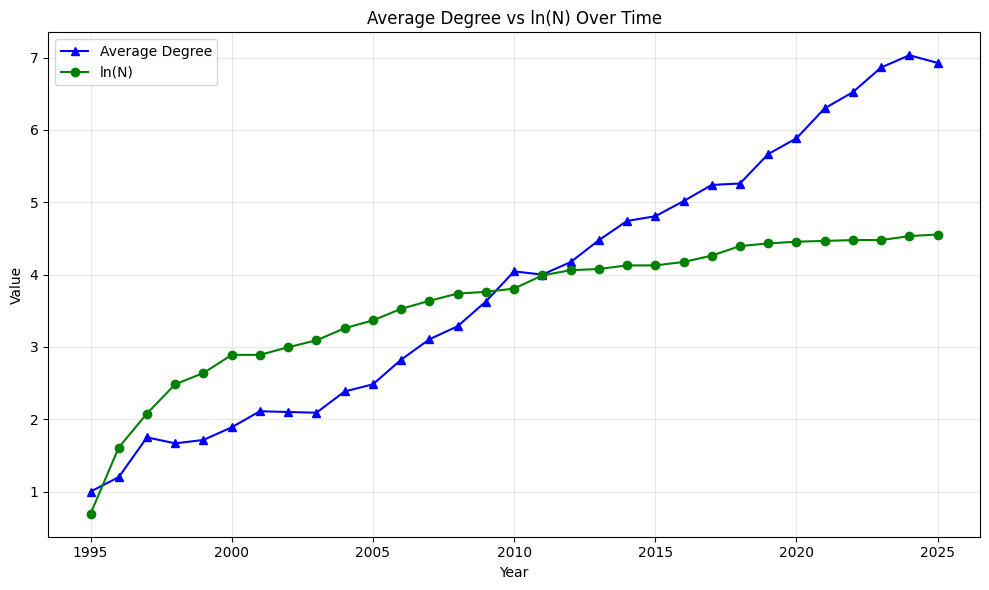

In [115]:
import numpy as np

import matplotlib.pyplot as plt

# Calculate average degrees and ln(N)
avg_degrees = [2 * num_edges[i] / num_nodes[i] if num_nodes[i] > 0 else 0 for i in range(len(years))]
ln_N = [np.log(n) for n in num_nodes]

# Plot both metrics
plt.figure(figsize=(10, 6))
plt.plot(years, avg_degrees, label='Average Degree', marker='^', color='blue')
plt.plot(years, ln_N, label='ln(N)', marker='o', color='green')

# Add labels, legend, and title
plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Average Degree vs ln(N) Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()


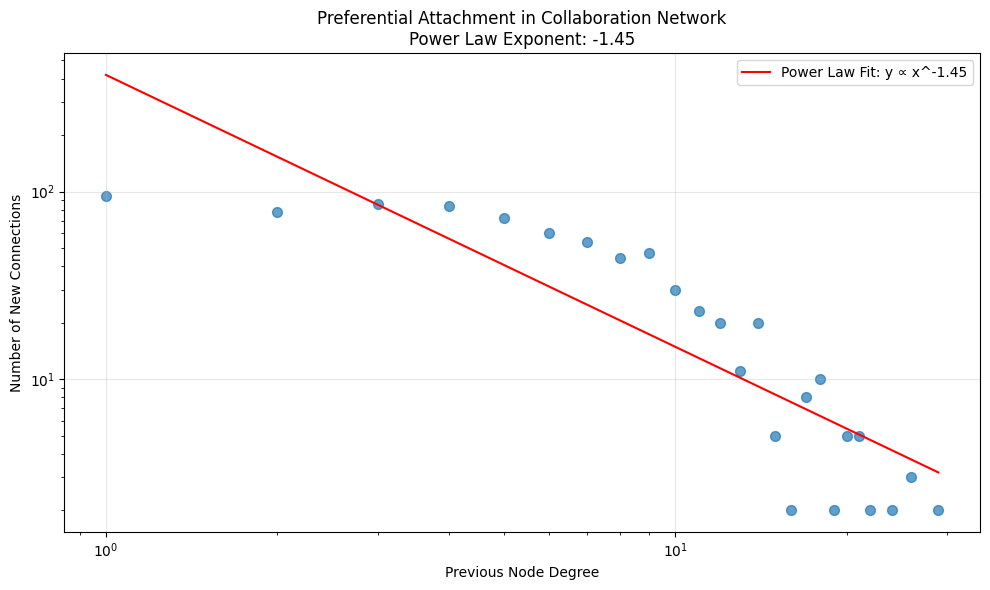

Preferential attachment detected with power law exponent: -1.45
This suggests that the probability of a new connection is proportional to degree^-1.45
Weak preferential attachment: degree has limited influence on gaining new connections


In [15]:
import numpy as np
from collections import defaultdict

import matplotlib.pyplot as plt

# Create a plot to visualize preferential attachment
def analyze_preferential_attachment(networks):
    # Sort years chronologically
    years = sorted(networks.keys())
    
    # We'll track node degrees over time and new connections
    degree_history = {}
    attachment_data = []
    
    # Initialize with first network
    current_network = networks[years[0]]
    for node in current_network.nodes():
        degree_history[node] = current_network.degree(node)
    
    # Go through networks year by year
    for i in range(1, len(years)):
        current_year = years[i]
        previous_year = years[i-1]
        
        current_network = networks[current_year]
        previous_network = networks[previous_year]
        
        # Find new edges
        current_edges = set(current_network.edges())
        previous_edges = set(previous_network.edges())
        new_edges = current_edges - previous_edges
        
        # For each new edge, record the degree of the nodes it connects to
        for u, v in new_edges:
            # Check if both nodes existed in previous network
            if u in previous_network.nodes() and v in previous_network.nodes():
                # Record previous degrees
                attachment_data.append((degree_history.get(u, 0), degree_history.get(v, 0)))
        
        # Update degree history
        for node in current_network.nodes():
            degree_history[node] = current_network.degree(node)
    
    # Process attachment data for visualization
    degrees = list(range(max(degree_history.values())+1))
    connections = defaultdict(int)
    
    for d1, d2 in attachment_data:
        connections[d1] += 1
        connections[d2] += 1
    
    # Convert to arrays for plotting
    x_degrees = []
    y_connections = []
    
    for degree in sorted(connections.keys()):
        if degree > 0:  # Ignore zero degree nodes
            x_degrees.append(degree)
            y_connections.append(connections[degree])
    
    # Plot data
    plt.figure(figsize=(10, 6))
    plt.scatter(x_degrees, y_connections, alpha=0.7, s=50)
    
    # Add best fit line (on log scale if data supports it)
    if len(x_degrees) > 2:
        # Try log-log fit to test for preferential attachment (power law)
        log_x = np.log(x_degrees)
        log_y = np.log(y_connections)
        
        # Linear regression on log-log data
        slope, intercept = np.polyfit(log_x, log_y, 1)
        
        # Plot power law fit
        x_fit = np.linspace(min(x_degrees), max(x_degrees), 100)
        y_fit = np.exp(intercept) * x_fit**slope
        
        plt.plot(x_fit, y_fit, 'r-', 
                 label=f'Power Law Fit: y ∝ x^{slope:.2f}')
        
        plt.title(f"Preferential Attachment in Collaboration Network\nPower Law Exponent: {slope:.2f}")
    else:
        plt.title("Preferential Attachment in Collaboration Network")
    
    plt.xlabel("Previous Node Degree")
    plt.ylabel("Number of New Connections")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Optional: use log-log scale if data has wide range
    if max(x_degrees) / min(x_degrees) > 10:
        plt.xscale('log')
        plt.yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    return slope if len(x_degrees) > 2 else None

# Run the analysis
power_law_exponent = analyze_preferential_attachment(networks)

if power_law_exponent:
    print(f"Preferential attachment detected with power law exponent: {power_law_exponent:.2f}")
    print(f"This suggests that the probability of a new connection is proportional to degree^{power_law_exponent:.2f}")
    
    # Determine strength of preferential attachment
    if power_law_exponent > 0.8:
        print("Strong preferential attachment: high-degree nodes are much more likely to gain new connections")
    elif power_law_exponent > 0.3:
        print("Moderate preferential attachment: high-degree nodes have some advantage in gaining new connections")
    else:
        print("Weak preferential attachment: degree has limited influence on gaining new connections")

In [12]:
# import networkx as nx
# from collections import Counter
# import matplotlib.pyplot as plt

# # Assume you already have your graph
# G = collaboration_network

# # Step 1: Separate nodes into groups
# group_a = {n for n, d in G.nodes(data=True) if d.get('position') == 'Associate Professor'}
# group_b = {n for n, d in G.nodes(data=True) if d.get('position') == 'Professor'}

# print(f"Group A (Associate Professors): {len(group_a)} nodes")
# print(f"Group B (Professors): {len(group_b)} nodes")

# # Step 2: Extract inter-group and intra-group edges
# inter_edges = [(u, v) for u, v in G.edges()
#                if (u in group_a and v in group_b) or (u in group_b and v in group_a)]

# intra_a = [(u, v) for u, v in G.edges() if u in group_a and v in group_a]
# intra_b = [(u, v) for u, v in G.edges() if u in group_b and v in group_b]

# # Step 3: Metrics
# possible_inter_edges = len(group_a) * len(group_b)
# inter_density = len(inter_edges) / possible_inter_edges if possible_inter_edges > 0 else 0

# print(f"\nInter-group edge count: {len(inter_edges)}")
# print(f"Inter-group density: {inter_density:.4f}")
# print(f"Intra-group edges in A: {len(intra_a)}")
# print(f"Intra-group edges in B: {len(intra_b)}")

# # Step 4: Conductance
# def volume(group):
#     return sum(dict(G.degree(n)).get(n, 0) for n in group)

# # vol_a = volume(group_a)
# # vol_b = volume(group_b)
# # conductance = len(inter_edges) / min(vol_a, vol_b) if min(vol_a, vol_b) > 0 else 0

# # print(f"Conductance: {conductance:.4f}")

# # Step 5: Modularity using ground truth
# # from networkx.algorithms.community.quality import modularity
# # mod = modularity(G, [group_a, group_b])
# # print(f"Modularity (based on position): {mod:.4f}")

# # Step 6: Identify bridge nodes
# bridge_counts = Counter()
# for u, v in inter_edges:
#     bridge_counts[u] += 1
#     bridge_counts[v] += 1

# top_bridges = bridge_counts.most_common(10)
# print("\nTop bridge nodes between groups:")
# for node, count in top_bridges:
#     print(f"{node}: {count} inter-group connections")

# # Step 7: Visualization
# pos = nx.spring_layout(G, seed=42)
# colors = ['skyblue' if n in group_a else 'salmon' if n in group_b else 'gray' for n in G.nodes]

# plt.figure(figsize=(10, 7))
# nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=100, alpha=0.8)
# nx.draw_networkx_edges(G, pos, edgelist=intra_a, edge_color='lightblue', alpha=0.4)
# nx.draw_networkx_edges(G, pos, edgelist=intra_b, edge_color='lightcoral', alpha=0.4)
# nx.draw_networkx_edges(G, pos, edgelist=inter_edges, edge_color='black', width=1)

# plt.title("Collaboration Network: Associate Professors vs. Professors")
# plt.axis('off')
# plt.show()


Distribution of faculty by position:
Associate Professor: 43 faculty
Assistant Professor: 35 faculty
Professor: 18 faculty
Lecturer: 8 faculty
Senior Lecturer: 5 faculty


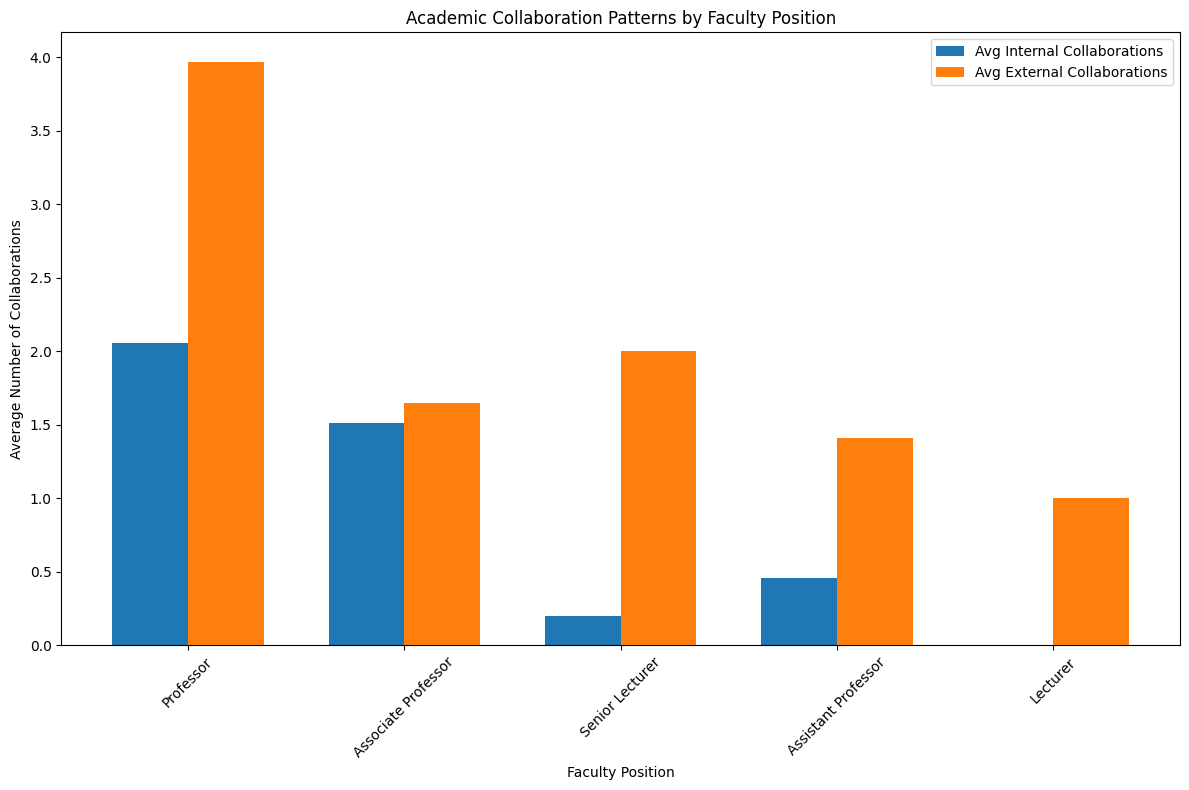

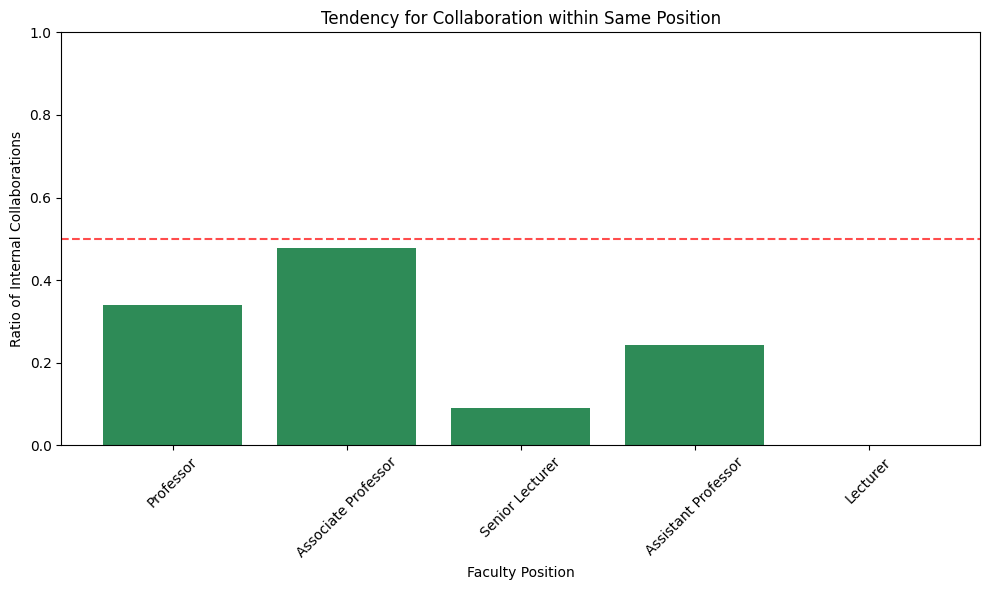

/var/folders/cv/0cclzv3d1rd6v4byjw0t0n480000gn/T/ipykernel_81822/3803871120.py:115: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.02857142857142857' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  position_matrix.loc[pos1, pos2] /= possible_connections
/var/folders/cv/0cclzv3d1rd6v4byjw0t0n480000gn/T/ipykernel_81822/3803871120.py:115: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.010714285714285714' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  position_matrix.loc[pos1, pos2] /= possible_connections
/var/folders/cv/0cclzv3d1rd6v4byjw0t0n480000gn/T/ipykernel_81822/3803871120.py:115: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.07936507936507936' has dty

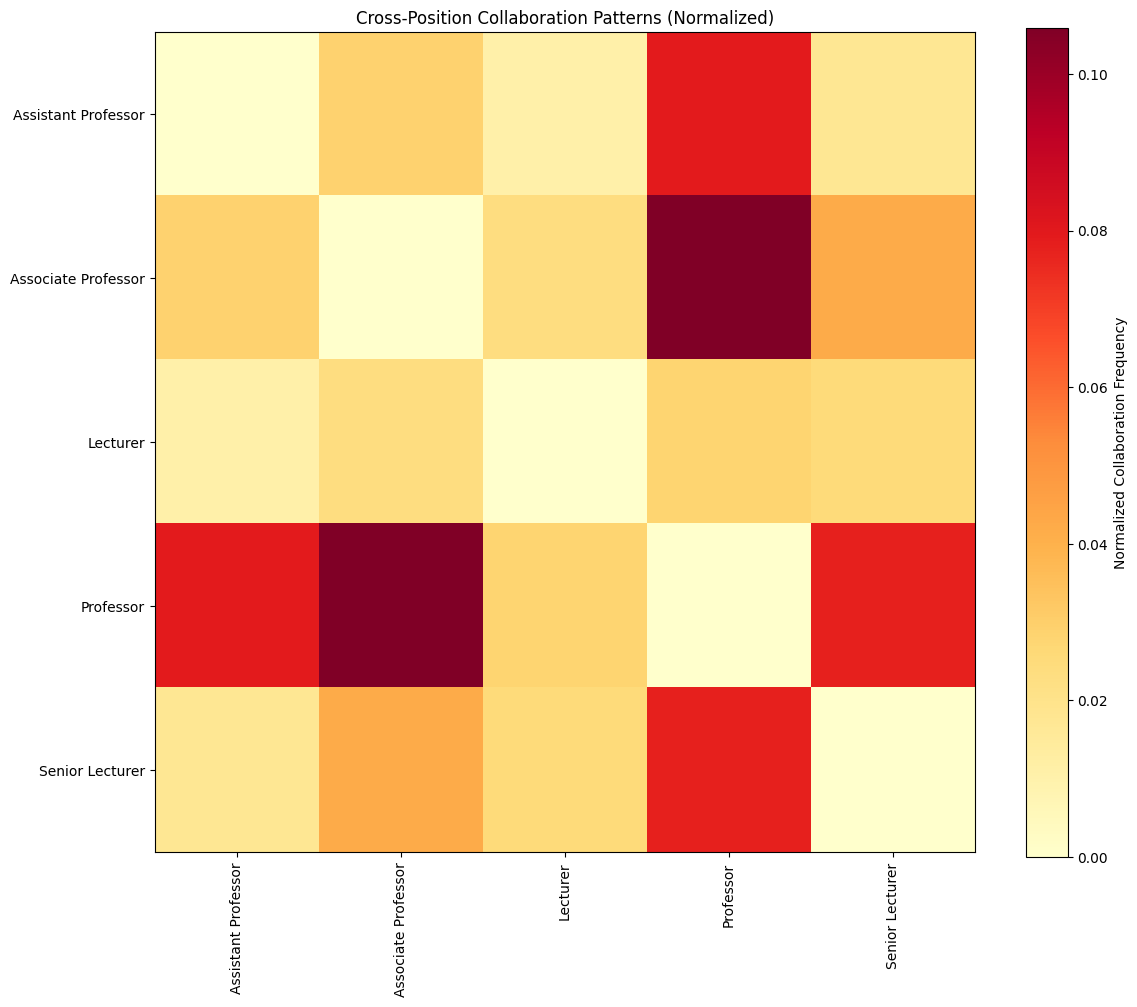

In [13]:
import networkx as nx
import numpy as np
import pandas as pd
from collections import defaultdict, Counter

import matplotlib.pyplot as plt

# Analyze collaboration patterns based on position attribute
# First, let's extract position information for each node
position_data = {}
node_positions = {}

# Get position attribute for each node
for node in collaboration_network.nodes():
    position = collaboration_network.nodes[node].get('position', 'Unknown')
    node_positions[node] = position
    
    if position not in position_data:
        position_data[position] = []
    position_data[position].append(node)

# Count the number of nodes in each position category
position_counts = {pos: len(nodes) for pos, nodes in position_data.items()}
print("Distribution of faculty by position:")
for pos, count in sorted(position_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{pos}: {count} faculty")

# Calculate internal and external collaborations for each position
position_collaborations = defaultdict(lambda: {'internal': 0, 'external': 0, 'nodes': 0})

for position, nodes in position_data.items():
    position_collaborations[position]['nodes'] = len(nodes)
    
    # Count internal collaborations (within same position)
    for node in nodes:
        for neighbor in collaboration_network.neighbors(node):
            neighbor_position = node_positions.get(neighbor, 'Unknown')
            
            if neighbor_position == position:
                position_collaborations[position]['internal'] += 0.5  # Count each edge once
            else:
                position_collaborations[position]['external'] += 0.5  # Count each edge once

# Convert the defaultdict to a dataframe
collab_df = pd.DataFrame.from_dict(position_collaborations, orient='index')
collab_df['avg_internal'] = collab_df['internal'] / collab_df['nodes']
collab_df['avg_external'] = collab_df['external'] / collab_df['nodes']
collab_df['total_collaborations'] = collab_df['internal'] + collab_df['external']
collab_df['avg_total'] = collab_df['total_collaborations'] / collab_df['nodes']
collab_df['internal_ratio'] = collab_df['internal'] / collab_df['total_collaborations']

# Sort by total collaborations
collab_df = collab_df.sort_values('avg_total', ascending=False)

# Create a bar chart comparing average internal vs external collaborations
plt.figure(figsize=(12, 8))
positions = collab_df.index
ind = np.arange(len(positions))
width = 0.35

# Filter out positions with very few faculty (optional)
min_faculty = 3
filtered_df = collab_df[collab_df['nodes'] >= min_faculty]
positions = filtered_df.index
ind = np.arange(len(positions))

plt.bar(ind, filtered_df['avg_internal'], width, label='Avg Internal Collaborations')
plt.bar(ind + width, filtered_df['avg_external'], width, label='Avg External Collaborations')

plt.xlabel('Faculty Position')
plt.ylabel('Average Number of Collaborations')
plt.title('Academic Collaboration Patterns by Faculty Position')
plt.xticks(ind + width/2, positions, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot the ratio of internal collaboration to total collaboration
plt.figure(figsize=(10, 6))
plt.bar(filtered_df.index, filtered_df['internal_ratio'], color='seagreen')
plt.axhline(y=0.5, linestyle='--', color='red', alpha=0.7)
plt.xlabel('Faculty Position')
plt.ylabel('Ratio of Internal Collaborations')
plt.title('Tendency for Collaboration within Same Position')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Analyze the collaboration across different positions
cross_position_edges = []
for u, v in collaboration_network.edges():
    pos_u = node_positions.get(u, 'Unknown')
    pos_v = node_positions.get(v, 'Unknown')
    if pos_u != pos_v and pos_u != 'Unknown' and pos_v != 'Unknown':
        cross_position_edges.append((pos_u, pos_v))

# Count the frequency of each collaboration type
cross_collab_counts = Counter(cross_position_edges)

# Create an adjacency matrix for position collaborations
unique_positions = sorted(position_data.keys())
position_matrix = pd.DataFrame(0, index=unique_positions, columns=unique_positions)

for (pos1, pos2), count in cross_collab_counts.items():
    position_matrix.loc[pos1, pos2] += count
    position_matrix.loc[pos2, pos1] += count  # Make it symmetric

# Normalize by the number of possible connections between groups
for i, pos1 in enumerate(unique_positions):
    for j, pos2 in enumerate(unique_positions):
        if i != j:
            possible_connections = len(position_data[pos1]) * len(position_data[pos2])
            if possible_connections > 0:
                position_matrix.loc[pos1, pos2] /= possible_connections

# Plot the position collaboration matrix as a heatmap
plt.figure(figsize=(12, 10))
plt.imshow(position_matrix, cmap='YlOrRd')
plt.colorbar(label='Normalized Collaboration Frequency')
plt.xticks(range(len(unique_positions)), unique_positions, rotation=90)
plt.yticks(range(len(unique_positions)), unique_positions)
plt.title('Cross-Position Collaboration Patterns (Normalized)')
plt.tight_layout()
plt.show()

Distribution of faculty by area:
AI/ML: 28 faculty
Computer Architecture: 13 faculty
Computer Vision: 12 faculty
Computer Networks: 10 faculty
Software Engg: 9 faculty
Cyber Security: 7 faculty
Distributed Systems: 7 faculty
HCI: 5 faculty
Computer Graphics: 4 faculty
Data Management: 3 faculty
Data Mining: 3 faculty
Multimedia: 3 faculty
Bioinformatics: 3 faculty
Information Retrieval: 2 faculty


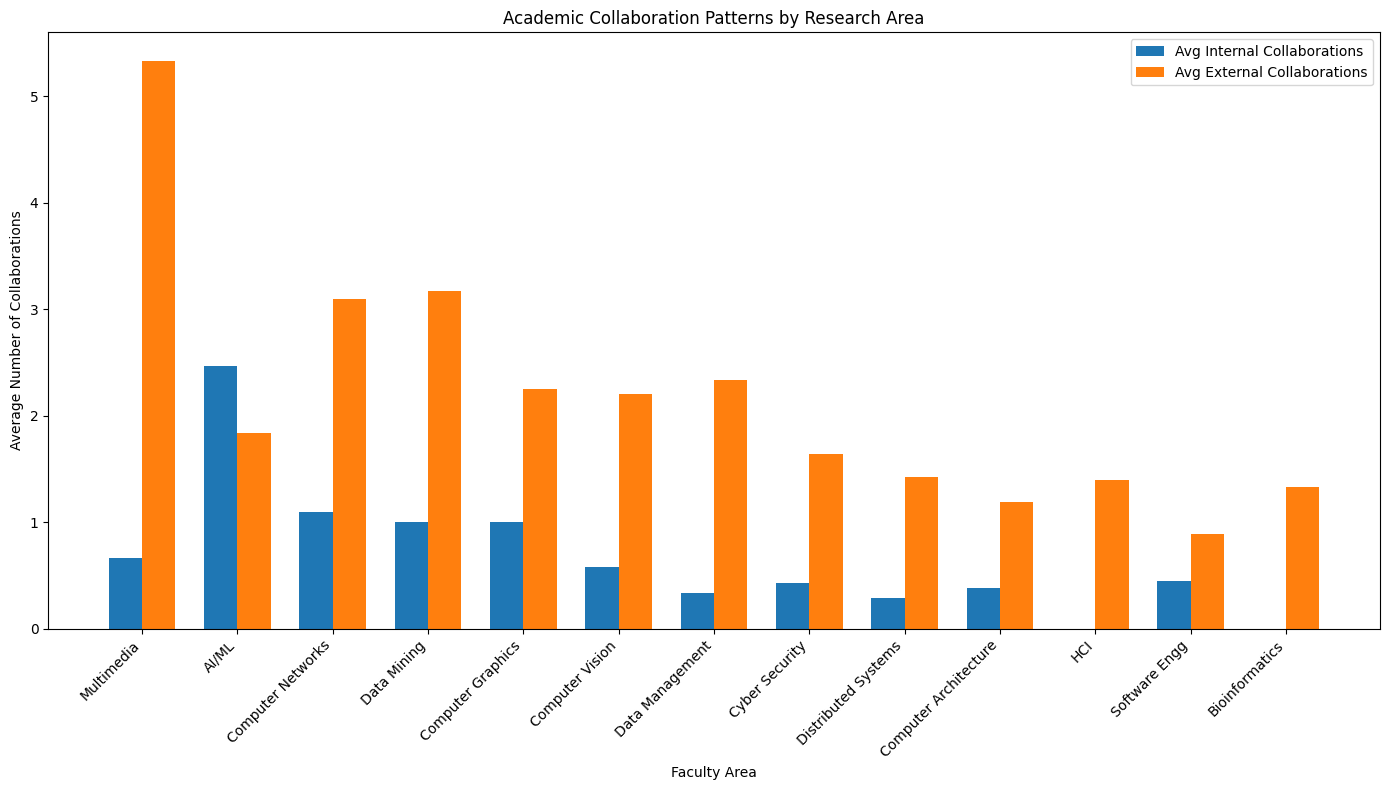

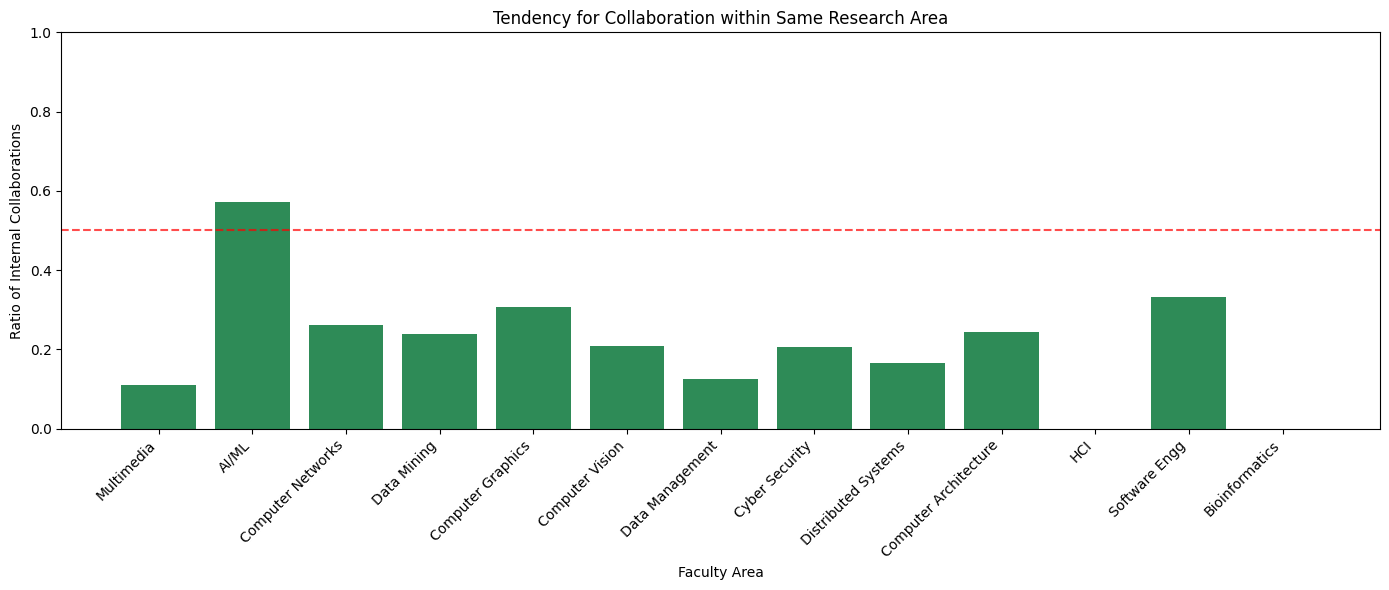

/var/folders/cv/0cclzv3d1rd6v4byjw0t0n480000gn/T/ipykernel_81822/1810135231.py:115: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.03571428571428571' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  area_matrix.loc[area1, area2] /= possible_connections
/var/folders/cv/0cclzv3d1rd6v4byjw0t0n480000gn/T/ipykernel_81822/1810135231.py:115: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.02197802197802198' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  area_matrix.loc[area1, area2] /= possible_connections
/var/folders/cv/0cclzv3d1rd6v4byjw0t0n480000gn/T/ipykernel_81822/1810135231.py:115: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.026785714285714284' has dtype i

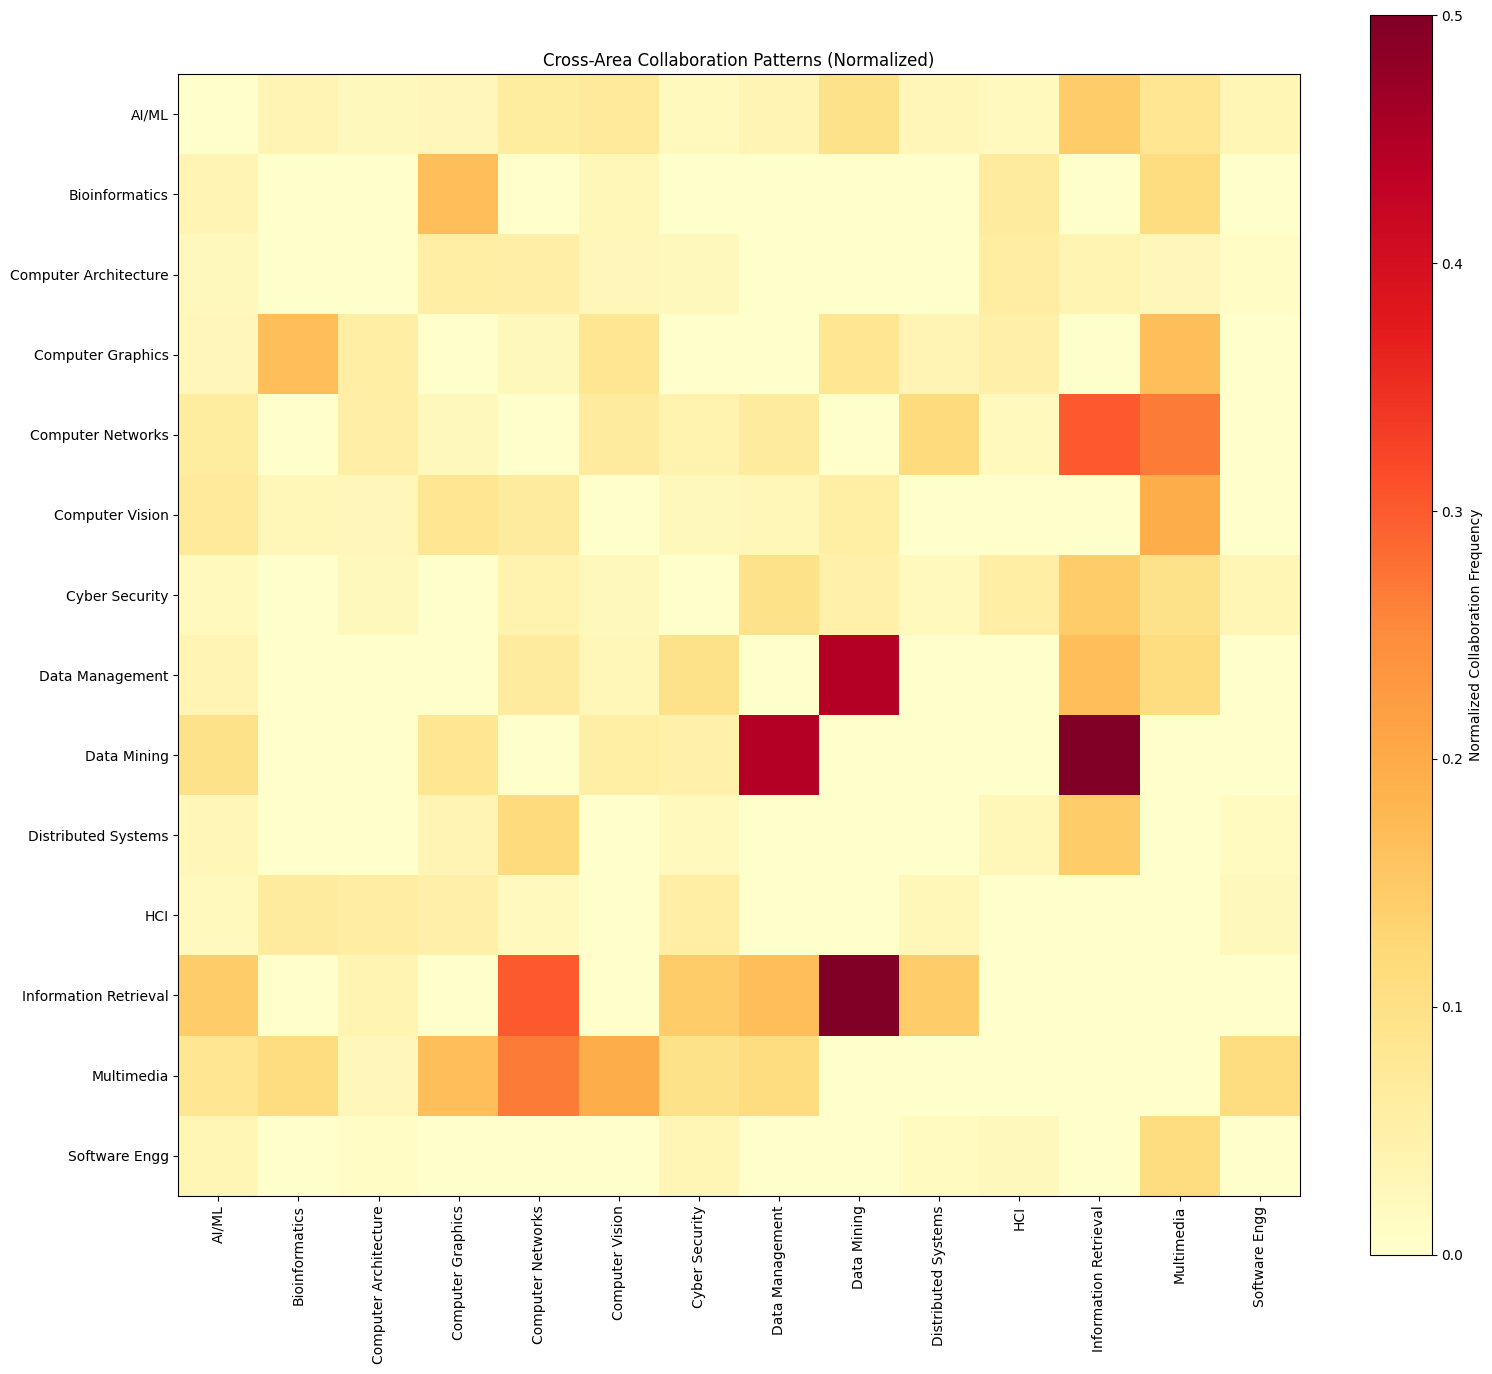

In [15]:
import networkx as nx
import numpy as np
import pandas as pd
from collections import defaultdict, Counter

import matplotlib.pyplot as plt

# Extract area information for each node
area_data = {}
node_areas = {}

# Get area attribute for each node
for node in collaboration_network.nodes():
    area = collaboration_network.nodes[node].get('area', 'Unknown')
    node_areas[node] = area
    
    if area not in area_data:
        area_data[area] = []
    area_data[area].append(node)

# Count the number of nodes in each area category
area_counts = {area: len(nodes) for area, nodes in area_data.items()}
print("Distribution of faculty by area:")
for area, count in sorted(area_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{area}: {count} faculty")

# Calculate internal and external collaborations for each area
area_collaborations = defaultdict(lambda: {'internal': 0, 'external': 0, 'nodes': 0})

for area, nodes in area_data.items():
    area_collaborations[area]['nodes'] = len(nodes)
    
    # Count internal collaborations (within same area)
    for node in nodes:
        for neighbor in collaboration_network.neighbors(node):
            neighbor_area = node_areas.get(neighbor, 'Unknown')
            
            if neighbor_area == area:
                area_collaborations[area]['internal'] += 0.5  # Count each edge once
            else:
                area_collaborations[area]['external'] += 0.5  # Count each edge once

# Convert the defaultdict to a dataframe
collab_df = pd.DataFrame.from_dict(area_collaborations, orient='index')
collab_df['avg_internal'] = collab_df['internal'] / collab_df['nodes']
collab_df['avg_external'] = collab_df['external'] / collab_df['nodes']
collab_df['total_collaborations'] = collab_df['internal'] + collab_df['external']
collab_df['avg_total'] = collab_df['total_collaborations'] / collab_df['nodes']
collab_df['internal_ratio'] = collab_df['internal'] / collab_df['total_collaborations'].replace(0, np.nan)

# Sort by total collaborations
collab_df = collab_df.sort_values('avg_total', ascending=False)

# Create a bar chart comparing average internal vs external collaborations
plt.figure(figsize=(14, 8))
areas = collab_df.index
ind = np.arange(len(areas))
width = 0.35

# Filter out areas with very few faculty
min_faculty = 3
filtered_df = collab_df[collab_df['nodes'] >= min_faculty]
areas = filtered_df.index
ind = np.arange(len(areas))

plt.bar(ind, filtered_df['avg_internal'], width, label='Avg Internal Collaborations')
plt.bar(ind + width, filtered_df['avg_external'], width, label='Avg External Collaborations')

plt.xlabel('Faculty Area')
plt.ylabel('Average Number of Collaborations')
plt.title('Academic Collaboration Patterns by Research Area')
plt.xticks(ind + width/2, areas, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Plot the ratio of internal collaboration to total collaboration
plt.figure(figsize=(14, 6))
plt.bar(filtered_df.index, filtered_df['internal_ratio'], color='seagreen')
plt.axhline(y=0.5, linestyle='--', color='red', alpha=0.7)
plt.xlabel('Faculty Area')
plt.ylabel('Ratio of Internal Collaborations')
plt.title('Tendency for Collaboration within Same Research Area')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Analyze the collaboration across different areas
cross_area_edges = []
for u, v in collaboration_network.edges():
    area_u = node_areas.get(u, 'Unknown')
    area_v = node_areas.get(v, 'Unknown')
    if area_u != area_v and area_u != 'Unknown' and area_v != 'Unknown':
        cross_area_edges.append((area_u, area_v))

# Count the frequency of each collaboration type
cross_collab_counts = Counter(cross_area_edges)

# Create an adjacency matrix for area collaborations
unique_areas = sorted([area for area in area_data.keys() if area != 'Unknown'])
area_matrix = pd.DataFrame(0, index=unique_areas, columns=unique_areas)

for (area1, area2), count in cross_collab_counts.items():
    if area1 in unique_areas and area2 in unique_areas:
        area_matrix.loc[area1, area2] += count
        area_matrix.loc[area2, area1] += count  # Make it symmetric

# Normalize by the number of possible connections between groups
for i, area1 in enumerate(unique_areas):
    for j, area2 in enumerate(unique_areas):
        if i != j:
            possible_connections = len(area_data[area1]) * len(area_data[area2])
            if possible_connections > 0:
                area_matrix.loc[area1, area2] /= possible_connections

# Plot the area collaboration matrix as a heatmap
plt.figure(figsize=(16, 14))
plt.imshow(area_matrix, cmap='YlOrRd')
plt.colorbar(label='Normalized Collaboration Frequency')
plt.xticks(range(len(unique_areas)), unique_areas, rotation=90)
plt.yticks(range(len(unique_areas)), unique_areas)
plt.title('Cross-Area Collaboration Patterns (Normalized)')
plt.tight_layout()
plt.show()

Distribution of faculty by management role:
N: 100 faculty
Y: 9 faculty


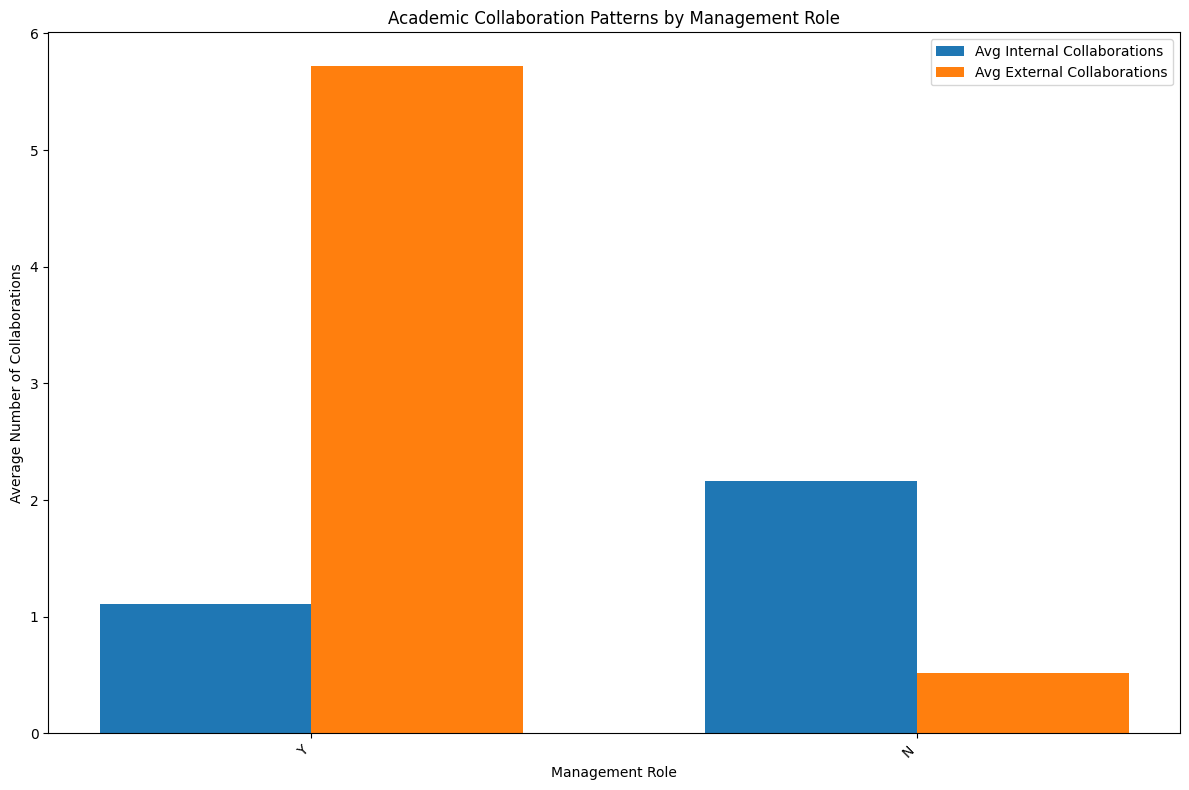

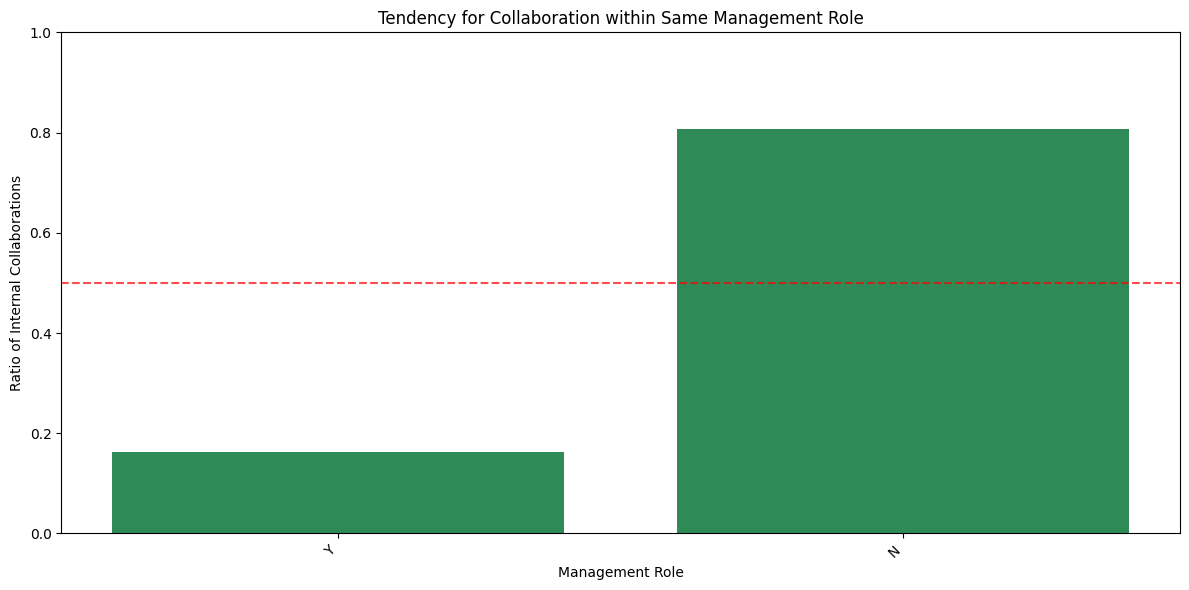

/var/folders/cv/0cclzv3d1rd6v4byjw0t0n480000gn/T/ipykernel_81822/1504507907.py:115: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.11444444444444445' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  management_matrix.loc[mgmt1, mgmt2] /= possible_connections
/var/folders/cv/0cclzv3d1rd6v4byjw0t0n480000gn/T/ipykernel_81822/1504507907.py:115: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.11444444444444445' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  management_matrix.loc[mgmt1, mgmt2] /= possible_connections


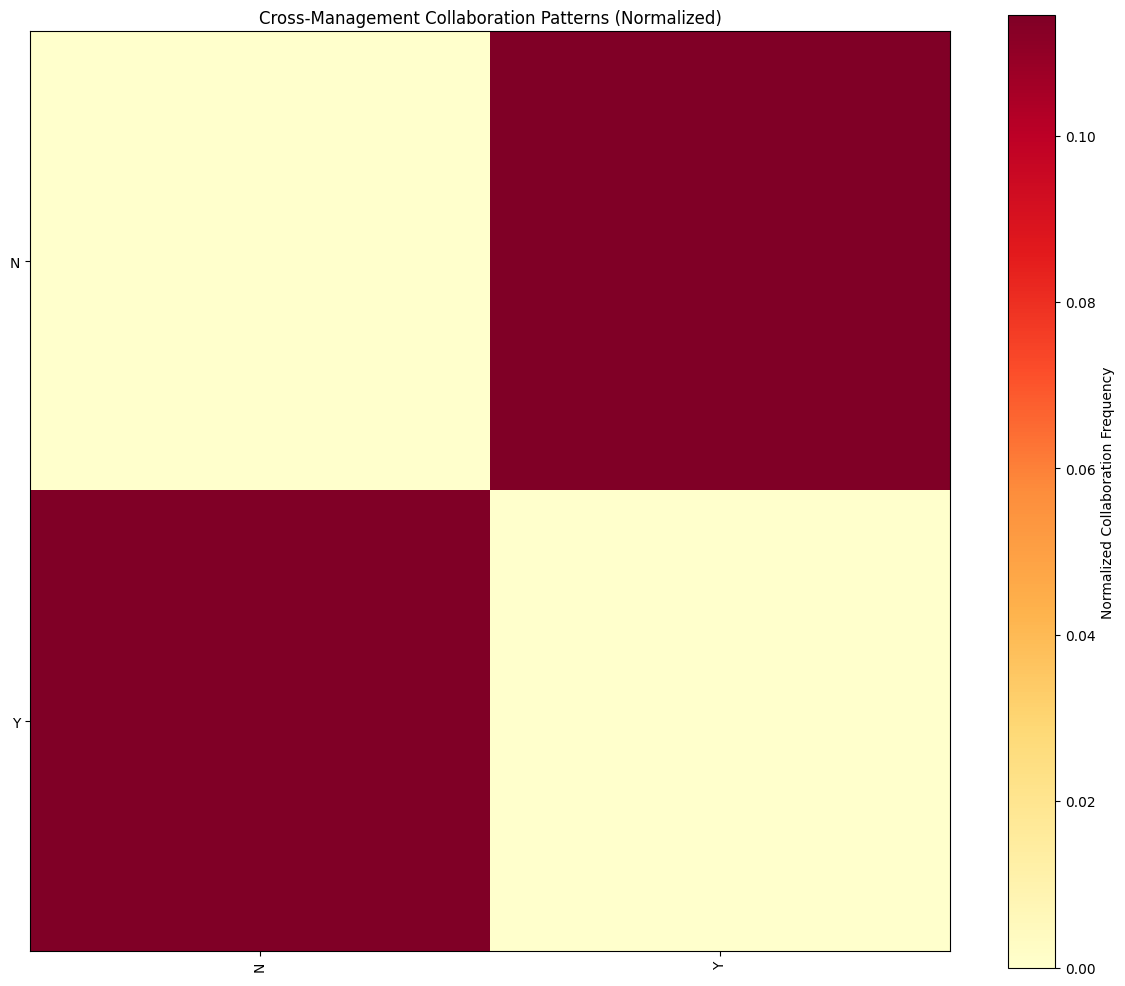

In [21]:
import networkx as nx
import numpy as np
import pandas as pd
from collections import defaultdict, Counter

import matplotlib.pyplot as plt

# Extract management information for each node
management_data = {}
node_management = {}

# Get management attribute for each node
for node in collaboration_network.nodes():
    management = collaboration_network.nodes[node].get('management', 'Unknown')
    node_management[node] = management
    
    if management not in management_data:
        management_data[management] = []
    management_data[management].append(node)

# Count the number of nodes in each management category
management_counts = {mgmt: len(nodes) for mgmt, nodes in management_data.items()}
print("Distribution of faculty by management role:")
for mgmt, count in sorted(management_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{mgmt}: {count} faculty")

# Calculate internal and external collaborations for each management category
management_collaborations = defaultdict(lambda: {'internal': 0, 'external': 0, 'nodes': 0})

for management, nodes in management_data.items():
    management_collaborations[management]['nodes'] = len(nodes)
    
    # Count internal collaborations (within same management)
    for node in nodes:
        for neighbor in collaboration_network.neighbors(node):
            neighbor_management = node_management.get(neighbor, 'Unknown')
            
            if neighbor_management == management:
                management_collaborations[management]['internal'] += 0.5  # Count each edge once
            else:
                management_collaborations[management]['external'] += 0.5  # Count each edge once

# Convert the defaultdict to a dataframe
collab_df = pd.DataFrame.from_dict(management_collaborations, orient='index')
collab_df['avg_internal'] = collab_df['internal'] / collab_df['nodes']
collab_df['avg_external'] = collab_df['external'] / collab_df['nodes']
collab_df['total_collaborations'] = collab_df['internal'] + collab_df['external']
collab_df['avg_total'] = collab_df['total_collaborations'] / collab_df['nodes']
collab_df['internal_ratio'] = collab_df['internal'] / collab_df['total_collaborations'].replace(0, np.nan)

# Sort by total collaborations
collab_df = collab_df.sort_values('avg_total', ascending=False)

# Create a bar chart comparing average internal vs external collaborations
plt.figure(figsize=(12, 8))
managements = collab_df.index
ind = np.arange(len(managements))
width = 0.35

# Filter out management categories with very few faculty
min_faculty = 3
filtered_df = collab_df[collab_df['nodes'] >= min_faculty]
managements = filtered_df.index
ind = np.arange(len(managements))

plt.bar(ind, filtered_df['avg_internal'], width, label='Avg Internal Collaborations')
plt.bar(ind + width, filtered_df['avg_external'], width, label='Avg External Collaborations')

plt.xlabel('Management Role')
plt.ylabel('Average Number of Collaborations')
plt.title('Academic Collaboration Patterns by Management Role')
plt.xticks(ind + width/2, managements, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Plot the ratio of internal collaboration to total collaboration
plt.figure(figsize=(12, 6))
plt.bar(filtered_df.index, filtered_df['internal_ratio'], color='seagreen')
plt.axhline(y=0.5, linestyle='--', color='red', alpha=0.7)
plt.xlabel('Management Role')
plt.ylabel('Ratio of Internal Collaborations')
plt.title('Tendency for Collaboration within Same Management Role')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Analyze the collaboration across different management roles
cross_management_edges = []
for u, v in collaboration_network.edges():
    mgmt_u = node_management.get(u, 'Unknown')
    mgmt_v = node_management.get(v, 'Unknown')
    if mgmt_u != mgmt_v and mgmt_u != 'Unknown' and mgmt_v != 'Unknown':
        cross_management_edges.append((mgmt_u, mgmt_v))

# Count the frequency of each collaboration type
cross_collab_counts = Counter(cross_management_edges)

# Create an adjacency matrix for management collaborations
unique_managements = sorted([mgmt for mgmt in management_data.keys() if mgmt != 'Unknown'])
management_matrix = pd.DataFrame(0, index=unique_managements, columns=unique_managements)

for (mgmt1, mgmt2), count in cross_collab_counts.items():
    if mgmt1 in unique_managements and mgmt2 in unique_managements:
        management_matrix.loc[mgmt1, mgmt2] += count
        management_matrix.loc[mgmt2, mgmt1] += count  # Make it symmetric

# Normalize by the number of possible connections between groups
for i, mgmt1 in enumerate(unique_managements):
    for j, mgmt2 in enumerate(unique_managements):
        if i != j:
            possible_connections = len(management_data[mgmt1]) * len(management_data[mgmt2])
            if possible_connections > 0:
                management_matrix.loc[mgmt1, mgmt2] /= possible_connections

# Plot the management collaboration matrix as a heatmap
plt.figure(figsize=(12, 10))
plt.imshow(management_matrix, cmap='YlOrRd')
plt.colorbar(label='Normalized Collaboration Frequency')
plt.xticks(range(len(unique_managements)), unique_managements, rotation=90)
plt.yticks(range(len(unique_managements)), unique_managements)
plt.title('Cross-Management Collaboration Patterns (Normalized)')
plt.tight_layout()
plt.show()

# Analysis of Collaboration by Research Area

## Key Findings:

1. **Productivity by Research Area**:
    - Multimedia researchers are the most collaborative, averaging 6 collaborations per faculty
    - Information Retrieval faculty show strong external collaboration (5.75 avg)
    - AI/ML has the largest group (28 faculty) with high average collaboration (4.3)

2. **Internal vs External Collaboration**:
    - AI/ML shows the strongest tendency to collaborate within its own field (57% internal)
    - Most research areas prefer external collaboration across disciplines
    - Three areas (Information Retrieval, HCI, Bioinformatics) show no internal collaboration

3. **Cross-Area Collaboration Patterns**:
    - Information Retrieval and Data Mining have strong collaborative ties
    - Multimedia researchers actively collaborate with Computer Networks
    - AI/ML serves as a central hub, collaborating across multiple domains

4. **Small but Connected Areas**:
    - Some smaller groups (Data Management, Bioinformatics) serve as connectors between domains
    - Computer Graphics shows diverse collaboration across multiple areas

This network structure demonstrates both specialization within research areas and interdisciplinary connections that foster innovation across traditional boundaries.

# Analysis of Node Collaboration by Position

## Key Findings:

1. **Faculty Distribution by Position**:
    - Associate Professors form the largest group (43 faculty)
    - Assistant Professors represent the second largest group (35 faculty)
    - Professors (18), Lecturers (8), and Senior Lecturers (5) make up the rest

2. **Collaboration Patterns**:
    - Professors have the highest rate of external collaboration (4.0 per faculty)
    - Associate Professors show strong internal collaboration within their rank
    - Assistant Professors have more connections outside their position group than within

3. **Cross-Position Collaboration**:
    - Professor-Associate Professor collaborations are the most frequent (over 10%)
    - Senior Lecturers and Professors show substantial connectivity (7.8%)
    - Lecturers have fewer overall connections but collaborate across all positions

4. **Bridge Nodes**:
    - Professor Chunyan Miao serves as the key bridge with 11 inter-position connections
    - Several faculty members (including Professors Dusit Niyato, Cuntai Guan, and Jianfei Cai) have 7 connections across position boundaries
    - These bridge nodes are critical for knowledge transfer across academic ranks

This analysis reveals that while there is natural collaboration within academic ranks, significant cross-position interaction occurs, supporting the integration of faculty at different career stages.

# Analysis of Management Roles in Collaboration Network

## Key Findings:

1. **Faculty Management Distribution**:
    - Faculty with management roles (Y) represent a small subset of the network (9 faculty members)
    - Non-management faculty (N) form the majority of the network (100 faculty members)

2. **Collaboration Patterns**:
    - Management faculty exhibit significantly higher average collaboration (6.8 collaborations per faculty)
    - Management faculty strongly prefer external collaborations (5.7 avg) over internal ones (1.1 avg)
    - Non-management faculty maintain more balanced collaboration patterns (2.7 avg total)

3. **Internal vs External Collaboration Ratio**:
    - Only 16% of management faculty collaborations occur within their management group
    - Non-management faculty show strong preference for internal collaborations (81%)
    - The high external collaboration ratio of management faculty suggests they serve as bridges

4. **Cross-Role Collaboration**:
    - Normalized collaboration frequency between roles is substantial (11.4%)
    - Cross-role connections may indicate effective leadership communication channels

This analysis reveals that faculty with management roles play a distinct function in the collaboration network, serving as connectors who work across organizational boundaries rather than collaborating primarily with other managers.*

In [22]:
import networkx as nx
import numpy as np
import pandas as pd
from collections import defaultdict, Counter

import matplotlib.pyplot as plt

class CollaborationAnalyzer:
    """
    A class for analyzing collaboration patterns between groups in a network.
    """
    
    def __init__(self, network, node_attributes=None):
        """
        Initialize the analyzer with a network and optional node attributes.
        
        Parameters:
        -----------
        network : networkx.Graph
            The collaboration network to analyze
        node_attributes : dict, optional
            Dictionary mapping node attributes to their values
        """
        self.network = network
        self.node_attributes = node_attributes or {}
        
        # Extract attributes from graph if not provided
        if not self.node_attributes:
            for node in self.network.nodes():
                self.node_attributes[node] = self.network.nodes[node]
    
    def analyze_by_attribute(self, attribute_name):
        """
        Analyze the network based on a specific node attribute.
        
        Parameters:
        -----------
        attribute_name : str
            The name of the attribute to analyze
            
        Returns:
        --------
        dict
            Dictionary containing analysis results
        """
        # Extract attribute values for each node
        attr_data = {}
        node_attrs = {}
        
        # Get attribute for each node
        for node in self.network.nodes():
            attr_value = self.network.nodes[node].get(attribute_name, 'Unknown')
            node_attrs[node] = attr_value
            
            if attr_value not in attr_data:
                attr_data[attr_value] = []
            attr_data[attr_value].append(node)
        
        # Count nodes in each category
        attr_counts = {attr: len(nodes) for attr, nodes in attr_data.items()}
        
        # Calculate internal and external collaborations
        attr_collaborations = defaultdict(lambda: {'internal': 0, 'external': 0, 'nodes': 0})
        
        for attr_value, nodes in attr_data.items():
            attr_collaborations[attr_value]['nodes'] = len(nodes)
            
            # Count collaborations
            for node in nodes:
                for neighbor in self.network.neighbors(node):
                    neighbor_attr = node_attrs.get(neighbor, 'Unknown')
                    
                    if neighbor_attr == attr_value:
                        attr_collaborations[attr_value]['internal'] += 0.5  # Count each edge once
                    else:
                        attr_collaborations[attr_value]['external'] += 0.5  # Count each edge once
        
        # Convert to DataFrame for easier analysis
        collab_df = pd.DataFrame.from_dict(attr_collaborations, orient='index')
        collab_df['avg_internal'] = collab_df['internal'] / collab_df['nodes']
        collab_df['avg_external'] = collab_df['external'] / collab_df['nodes']
        collab_df['total_collaborations'] = collab_df['internal'] + collab_df['external']
        collab_df['avg_total'] = collab_df['total_collaborations'] / collab_df['nodes']
        collab_df['internal_ratio'] = collab_df['internal'] / collab_df['total_collaborations'].replace(0, np.nan)
        
        # Analyze cross-group collaborations
        cross_edges = []
        for u, v in self.network.edges():
            attr_u = node_attrs.get(u, 'Unknown')
            attr_v = node_attrs.get(v, 'Unknown')
            if attr_u != attr_v and attr_u != 'Unknown' and attr_v != 'Unknown':
                cross_edges.append((attr_u, attr_v))
        
        # Count frequencies
        cross_collab_counts = Counter(cross_edges)
        
        # Create adjacency matrix
        unique_attrs = sorted([attr for attr in attr_data.keys() if attr != 'Unknown'])
        attr_matrix = pd.DataFrame(0, index=unique_attrs, columns=unique_attrs)
        
        for (attr1, attr2), count in cross_collab_counts.items():
            if attr1 in unique_attrs and attr2 in unique_attrs:
                attr_matrix.loc[attr1, attr2] += count
                attr_matrix.loc[attr2, attr1] += count  # Make it symmetric
        
        # Normalize by possible connections
        for i, attr1 in enumerate(unique_attrs):
            for j, attr2 in enumerate(unique_attrs):
                if i != j:
                    possible_connections = len(attr_data[attr1]) * len(attr_data[attr2])
                    if possible_connections > 0:
                        attr_matrix.loc[attr1, attr2] /= possible_connections
        
        # Identify bridge nodes
        bridge_counts = Counter()
        for u, v in cross_edges:
            node_u = None
            node_v = None
            for node, neighbors in self.network.adj.items():
                attr_node = node_attrs.get(node, 'Unknown')
                if attr_node == u:
                    for neighbor in neighbors:
                        if node_attrs.get(neighbor, 'Unknown') == v:
                            bridge_counts[node] += 1
                if attr_node == v:
                    for neighbor in neighbors:
                        if node_attrs.get(neighbor, 'Unknown') == u:
                            bridge_counts[node] += 1
        
        # Return analysis results
        return {
            'attr_data': attr_data,
            'attr_counts': attr_counts,
            'collaborations_df': collab_df, 
            'cross_edges': cross_edges,
            'cross_collab_counts': cross_collab_counts,
            'adjacency_matrix': attr_matrix,
            'bridge_nodes': bridge_counts.most_common(10),
            'node_attrs': node_attrs
        }
    
    def plot_internal_external_collaborations(self, analysis_results, min_nodes=3, title=None):
        """
        Plot internal vs external collaborations for each group.
        
        Parameters:
        -----------
        analysis_results : dict
            Results from analyze_by_attribute method
        min_nodes : int, optional
            Minimum number of nodes for a group to be included in plot
        title : str, optional
            Plot title
        """
        collab_df = analysis_results['collaborations_df']
        
        # Filter out groups with few members
        filtered_df = collab_df[collab_df['nodes'] >= min_nodes]
        groups = filtered_df.index
        ind = np.arange(len(groups))
        width = 0.35
        
        plt.figure(figsize=(12, 8))
        plt.bar(ind, filtered_df['avg_internal'], width, label='Avg Internal Collaborations')
        plt.bar(ind + width, filtered_df['avg_external'], width, label='Avg External Collaborations')
        
        plt.xlabel('Group')
        plt.ylabel('Average Number of Collaborations')
        plt.title(title or 'Internal vs External Collaborations by Group')
        plt.xticks(ind + width/2, groups, rotation=45, ha='right')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
    def plot_internal_ratio(self, analysis_results, min_nodes=3, title=None):
        """
        Plot the ratio of internal collaborations to total collaborations.
        
        Parameters:
        -----------
        analysis_results : dict
            Results from analyze_by_attribute method
        min_nodes : int, optional
            Minimum number of nodes for a group to be included in plot
        title : str, optional
            Plot title
        """
        collab_df = analysis_results['collaborations_df']
        
        # Filter out groups with few members
        filtered_df = collab_df[collab_df['nodes'] >= min_nodes]
        
        plt.figure(figsize=(12, 6))
        plt.bar(filtered_df.index, filtered_df['internal_ratio'], color='seagreen')
        plt.axhline(y=0.5, linestyle='--', color='red', alpha=0.7)
        plt.xlabel('Group')
        plt.ylabel('Ratio of Internal Collaborations')
        plt.title(title or 'Tendency for Internal Collaboration')
        plt.xticks(rotation=45, ha='right')
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()
        
    def plot_collaboration_heatmap(self, analysis_results, title=None):
        """
        Plot a heatmap of normalized cross-group collaborations.
        
        Parameters:
        -----------
        analysis_results : dict
            Results from analyze_by_attribute method
        title : str, optional
            Plot title
        """
        attr_matrix = analysis_results['adjacency_matrix']
        
        plt.figure(figsize=(12, 10))
        plt.imshow(attr_matrix, cmap='YlOrRd')
        plt.colorbar(label='Normalized Collaboration Frequency')
        plt.xticks(range(len(attr_matrix.columns)), attr_matrix.columns, rotation=90)
        plt.yticks(range(len(attr_matrix.index)), attr_matrix.index)
        plt.title(title or 'Cross-Group Collaboration Patterns (Normalized)')
        plt.tight_layout()
        plt.show()
    
    def generate_summary_report(self, analysis_results, attribute_name, min_nodes=3, top_n=5):
        """
        Generate a textual summary report of collaboration patterns.
        
        Parameters:
        -----------
        analysis_results : dict
            Results from analyze_by_attribute method
        attribute_name : str
            The name of the attribute analyzed
        min_nodes : int, optional
            Minimum number of nodes to include in report
        top_n : int, optional
            Number of top collaborations to report
            
        Returns:
        --------
        str
            Markdown formatted report
        """
        collab_df = analysis_results['collaborations_df']
        attr_counts = analysis_results['attr_counts']
        bridge_nodes = analysis_results['bridge_nodes']
        adj_matrix = analysis_results['adjacency_matrix']
        
        # Filter and sort
        filtered_df = collab_df[collab_df['nodes'] >= min_nodes].sort_values('avg_total', ascending=False)
        
        # Generate report
        report = f"# Analysis of Collaboration by {attribute_name}\n\n"
        report += "## Key Findings:\n\n"
        
        # Distribution summary
        report += "1. **Distribution by " + attribute_name + "**:\n"
        for group, count in sorted(attr_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]:
            report += f"    - {group}: {count} members\n"
        report += "\n"
        
        # Collaboration patterns
        report += f"2. **Collaboration Patterns**:\n"
        for group in filtered_df.index[:top_n]:
            internal = filtered_df.loc[group, 'avg_internal']
            external = filtered_df.loc[group, 'avg_external']
            total = filtered_df.loc[group, 'avg_total']
            report += f"    - {group} has {total:.1f} avg collaborations "
            if internal > external:
                report += f"(mostly internal: {internal:.1f})\n"
            else:
                report += f"(mostly external: {external:.1f})\n"
        report += "\n"
        
        # Internal vs External collaboration ratio
        report += "3. **Internal vs External Collaboration**:\n"
        for group in filtered_df.sort_values('internal_ratio', ascending=False).index[:top_n]:
            ratio = filtered_df.loc[group, 'internal_ratio'] * 100
            report += f"    - {group}: {ratio:.0f}% internal collaboration\n"
        report += "\n"
        
        # Cross-group collaborations
        report += "4. **Strong Cross-Group Connections**:\n"
        # Get top collaborations from adjacency matrix
        flat_adj = adj_matrix.unstack()
        flat_adj = flat_adj[flat_adj > 0].sort_values(ascending=False)
        for i, ((group1, group2), value) in enumerate(flat_adj.items()):
            if i >= top_n:
                break
            if group1 != group2:
                report += f"    - {group1} ↔ {group2}: {value:.2f} normalized connection strength\n"
        report += "\n"
        
        # Bridge nodes
        if bridge_nodes:
            report += "5. **Key Bridge Nodes**:\n"
            for node, count in bridge_nodes[:top_n]:
                report += f"    - {node}: {count} cross-group connections\n"
                
        return report

# Example usage:
# analyzer = CollaborationAnalyzer(collaboration_network)
# area_analysis = analyzer.analyze_by_attribute('area')
# analyzer.plot_internal_external_collaborations(area_analysis, title='Collaboration by Research Area')
# analyzer.plot_internal_ratio(area_analysis)
# analyzer.plot_collaboration_heatmap(area_analysis)
# report = analyzer.generate_summary_report(area_analysis, 'Research Area')
# print(report)

/var/folders/cv/0cclzv3d1rd6v4byjw0t0n480000gn/T/ipykernel_81822/3305120771.py:112: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.03571428571428571' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  attr_matrix.loc[attr1, attr2] /= possible_connections
/var/folders/cv/0cclzv3d1rd6v4byjw0t0n480000gn/T/ipykernel_81822/3305120771.py:112: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.02197802197802198' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  attr_matrix.loc[attr1, attr2] /= possible_connections
/var/folders/cv/0cclzv3d1rd6v4byjw0t0n480000gn/T/ipykernel_81822/3305120771.py:112: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.026785714285714284' has dtype i

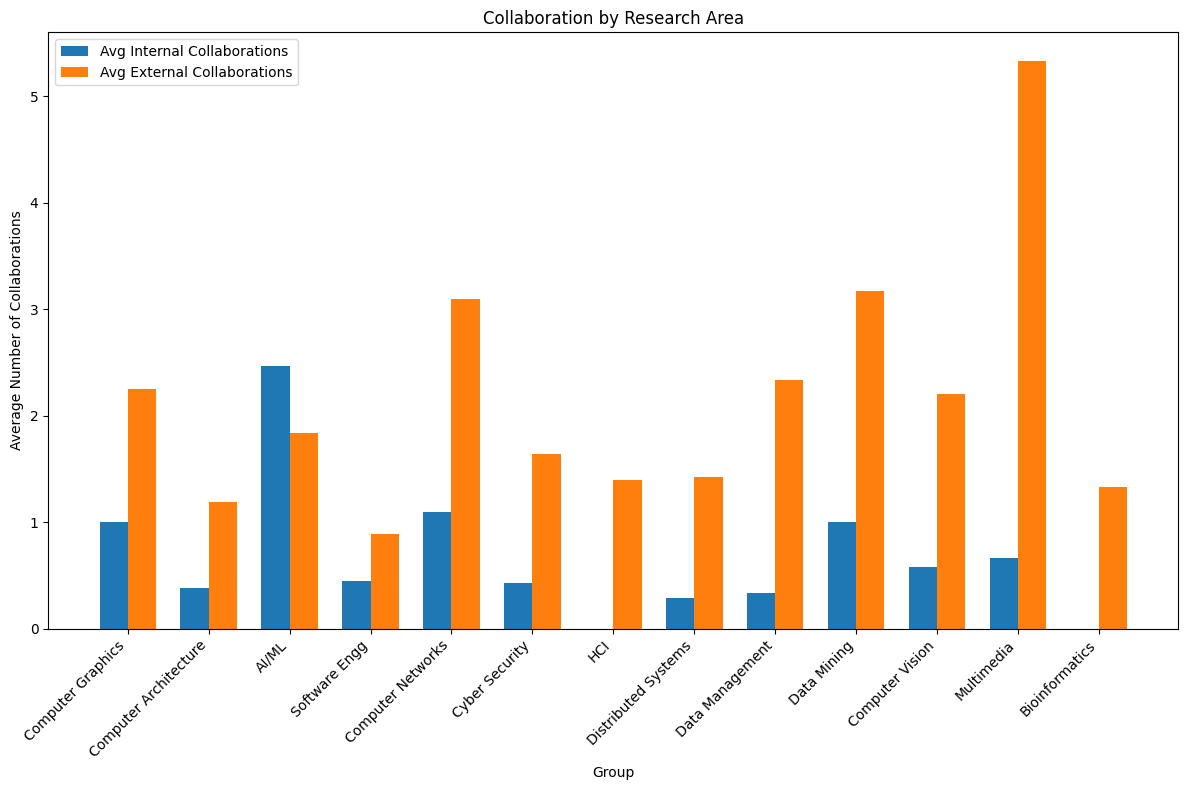

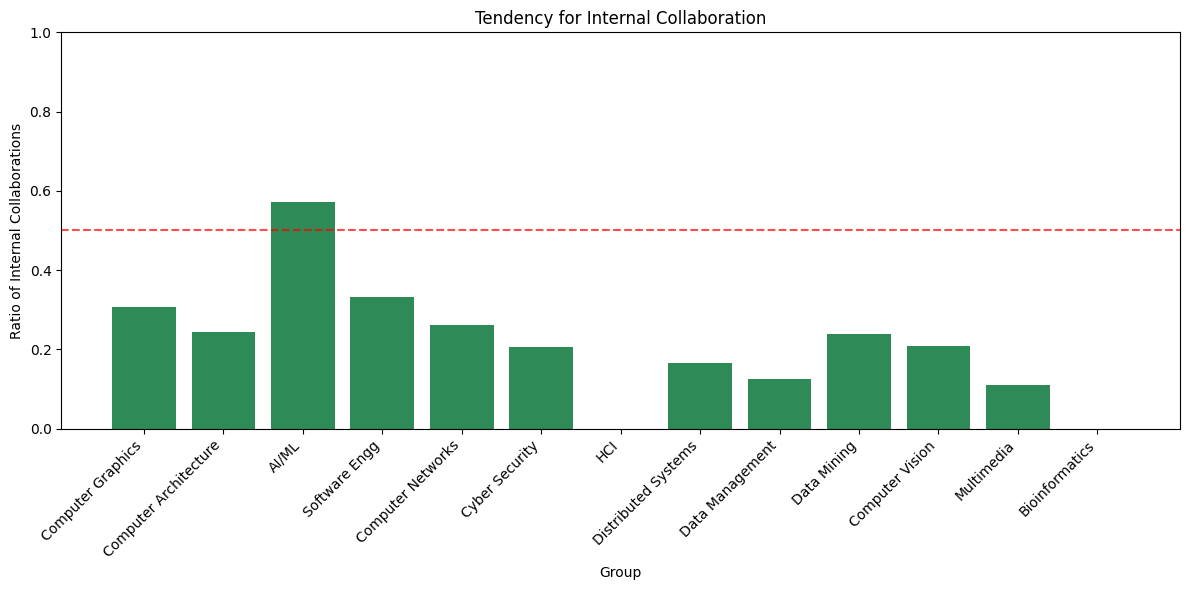

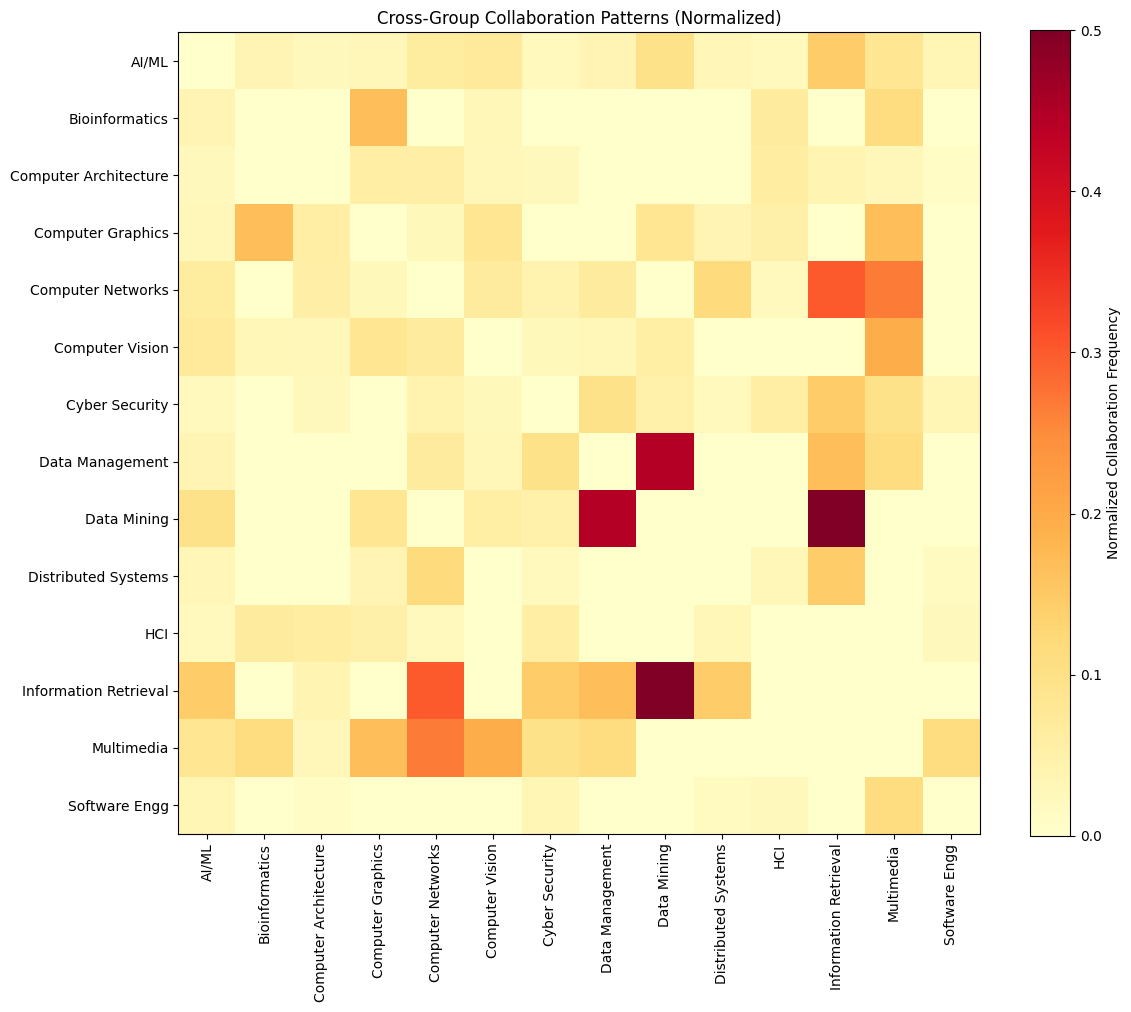

# Analysis of Collaboration by Research Area

## Key Findings:

1. **Distribution by Research Area**:
    - AI/ML: 28 members
    - Computer Architecture: 13 members
    - Computer Vision: 12 members
    - Computer Networks: 10 members
    - Software Engg: 9 members

2. **Collaboration Patterns**:
    - Multimedia has 6.0 avg collaborations (mostly external: 5.3)
    - AI/ML has 4.3 avg collaborations (mostly internal: 2.5)
    - Computer Networks has 4.2 avg collaborations (mostly external: 3.1)
    - Data Mining has 4.2 avg collaborations (mostly external: 3.2)
    - Computer Graphics has 3.2 avg collaborations (mostly external: 2.2)

3. **Internal vs External Collaboration**:
    - AI/ML: 57% internal collaboration
    - Software Engg: 33% internal collaboration
    - Computer Graphics: 31% internal collaboration
    - Computer Networks: 26% internal collaboration
    - Computer Architecture: 24% internal collaboration

4. **Strong Cross-Group Connections**:
    - Data Mining ↔ Info

In [23]:
analyzer = CollaborationAnalyzer(collaboration_network)
area_analysis = analyzer.analyze_by_attribute('area')
analyzer.plot_internal_external_collaborations(area_analysis, title='Collaboration by Research Area')
analyzer.plot_internal_ratio(area_analysis)
analyzer.plot_collaboration_heatmap(area_analysis)
report = analyzer.generate_summary_report(area_analysis, 'Research Area')
print(report)